In [1]:
# --- Power control ---
import nidaqmx # ND filter motor
from pylablib.devices.Thorlabs import MFF # Flip mount
from pylablib.devices.Thorlabs import PM160 # Power meter

# --- SLM ---
import HEDS
from hedslib.heds_types import *
"""
# --- Andor ---
import pylablib as pll
pll.par["devices/dlls/andor_shamrock"] = "C:/Program Files/Andor SDK/Shamrock64"
pll.par["devices/dlls/andor_sdk2"] = "C:/Program Files/Andor SDK"
from pylablib.devices import Andor
"""
# --- Rotation mount ---
from thorlabs_elliptec import ELLx, ELLError, ELLStatus, list_devices
import thorlabs_elliptec

In [2]:
from instruments.nd_filter_motor import NDFilterMotor
from instruments.slm import SLMController
from instruments.power_meter import PowerMeter
from instruments.flip_mount import FlipMount
from instruments.rotation_mount import RotationMount
#from instruments.spectrometer import AndorSpectrometer

In [3]:
from controllers.power_control import set_power
from controllers.polarization_scan import polarization_scan
#from controllers.polarized_spectroscopy import measure_polarized_spectra

SyntaxError: invalid syntax (power_control.py, line 16)

In [5]:
"""
from processing.peak_fitting import fit_n_peaks, fit_all_spectra
from processing.polarization_fitting import intensity_with_optics, degenerate_raman_intensity
from scipy.optimize import curve_fit
"""
import numpy as np

In [4]:
import pyvisa as pvisa
rm = pvisa.ResourceManager()
resources = rm.list_resources()
print("List")
for res in resources:
    print(res)

List


In [6]:
nd = NDFilterMotor()
slm = SLMController()
pm1 = PowerMeter('USB0::0x1313::0x8078::P0005244::0::INSTR')
pm2 = PowerMeter('USB0::0x1313::0x8078::PM001388::0::INSTR')
fm = FlipMount("37000705")
rm1 = RotationMount()
rm1.home()
rm2 = RotationMount(port=rm1.stage, device_id=2)
rm2.home()
#spec = AndorSpectrometer()

C:\Users\HP\.conda\envs\LL_Group_qcodes\lib\site-packages\pylablib\devices\Thorlabs\kinesis.py:230: UserWarning: model number MFF002 doesn't match the device ID prefix 37(MFF10.)
  warnings.warn("model number {} doesn't match the device ID prefix {}({})".format(model_no,port,port_model_no))


In [17]:
#spec = AndorSpectrometer(grating=2)

[Init] Cooler: True, T=-55.0099983215332 °C, Status=not_reached


In [22]:
# Close before restart the kernel
nd.close()
slm.close()
pm1.close()
pm2.close()
fm.close()
rm1.close()
rm2.close()
#spec.close()

[AndorSpectrometer] Devices closed.


In [20]:
# --- Parameters of spectrum ---
wavelength = 532
exp = 1
unit = "cm-1"
spec.set_grating(1200)
spec.set_exposure_time(exp)
spec.center_setting(center_value=1000, unit=unit, laser_wavelength=wavelength)

spec.check_ccd_temperature()
spec.print_spectrometer_parameters()

# --- Parameters of power meter
pm1.set_wavelength(wavelength)
print("Power meter: ", pm1.get_status())
pm2.set_wavelength(wavelength)
print("Power meter: ", pm2.get_status())

#set_power(setpoint=90e-6,tolerance=1e-6,flip_mount=fm,pm=pm1,motor=nd)

[Grating] Set to 1200 g/mm
[Exposure] Exposure time set to 1 s
[CCD] Temperature = -54.81999969482422 °C, Status = not_reached
[Spectrometer Parameters]
 Exposure time: 1.0
 Grating: 2
 Grating offset: -32
 Center: 5.618927001953125e-07
Power meter:  {'mode': 'power', 'autorange': True, 'wavelength': 5.32e-07, 'range': 1.849369e-05, 'reading': 4.62362344e-08}
Power meter:  {'mode': 'power', 'autorange': True, 'wavelength': 5.32e-07, 'range': 4.974785e-05, 'reading': 3.82255894e-05}


In [9]:
rm1.home()
rm2.home()

In [8]:
rm1.move_to(45)
rm2.move_to(45)

Polarizer steps: [  0.  15.  30.  45.  60.  75.  90. 105. 120. 135. 150. 165. 180. 195.
 210. 225. 240. 255. 270. 285. 300. 315. 330. 345.   0.]
QWP steps: [  0   9  18  27  36  45  54  63  72  81  90  99 108 117 126 135 144 153
 162 171 180]

Setting QWP to 0.0°
  Polarizer 0.0°, QWP 0.0° → 1.5761e-04 W
  Polarizer 15.0°, QWP 0.0° → 5.3485e-04 W
  Polarizer 30.0°, QWP 0.0° → 1.0772e-03 W
  Polarizer 45.0°, QWP 0.0° → 1.6470e-03 W
  Polarizer 60.0°, QWP 0.0° → 2.0407e-03 W
  Polarizer 75.0°, QWP 0.0° → 2.2249e-03 W
  Polarizer 90.0°, QWP 0.0° → 2.0991e-03 W
  Polarizer 105.0°, QWP 0.0° → 1.7204e-03 W
  Polarizer 120.0°, QWP 0.0° → 1.1941e-03 W
  Polarizer 135.0°, QWP 0.0° → 6.4858e-04 W
  Polarizer 150.0°, QWP 0.0° → 2.2831e-04 W
  Polarizer 165.0°, QWP 0.0° → 4.4334e-05 W
  Polarizer 180.0°, QWP 0.0° → 1.5134e-04 W
  Polarizer 195.0°, QWP 0.0° → 5.2391e-04 W
  Polarizer 210.0°, QWP 0.0° → 1.0616e-03 W
  Polarizer 225.0°, QWP 0.0° → 1.6320e-03 W
  Polarizer 240.0°, QWP 0.0° → 2.0396e-0

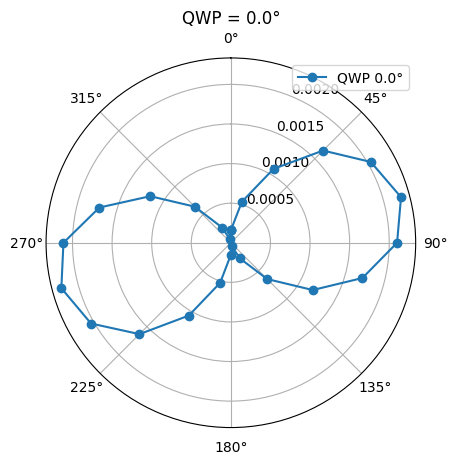


Setting QWP to 9.0°
  Polarizer 0.0°, QWP 9.0° → 4.4357e-04 W
  Polarizer 15.0°, QWP 9.0° → 9.4828e-04 W
  Polarizer 30.0°, QWP 9.0° → 1.4994e-03 W
  Polarizer 45.0°, QWP 9.0° → 1.9474e-03 W
  Polarizer 60.0°, QWP 9.0° → 2.2286e-03 W
  Polarizer 75.0°, QWP 9.0° → 2.1625e-03 W
  Polarizer 90.0°, QWP 9.0° → 1.8478e-03 W
  Polarizer 105.0°, QWP 9.0° → 1.3246e-03 W
  Polarizer 120.0°, QWP 9.0° → 7.8973e-04 W
  Polarizer 135.0°, QWP 9.0° → 3.3542e-04 W
  Polarizer 150.0°, QWP 9.0° → 8.9341e-05 W
  Polarizer 165.0°, QWP 9.0° → 1.2380e-04 W
  Polarizer 180.0°, QWP 9.0° → 4.3271e-04 W
  Polarizer 195.0°, QWP 9.0° → 9.5001e-04 W
  Polarizer 210.0°, QWP 9.0° → 1.5083e-03 W
  Polarizer 225.0°, QWP 9.0° → 1.9631e-03 W
  Polarizer 240.0°, QWP 9.0° → 2.1890e-03 W
  Polarizer 255.0°, QWP 9.0° → 2.1777e-03 W
  Polarizer 270.0°, QWP 9.0° → 1.8509e-03 W
  Polarizer 285.0°, QWP 9.0° → 1.3626e-03 W
  Polarizer 300.0°, QWP 9.0° → 7.8936e-04 W
  Polarizer 315.0°, QWP 9.0° → 3.3113e-04 W
  Polarizer 330.0°,

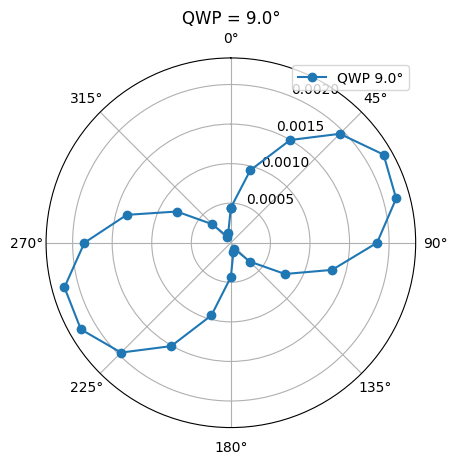


Setting QWP to 18.0°
  Polarizer 0.0°, QWP 18.0° → 7.7523e-04 W
  Polarizer 15.0°, QWP 18.0° → 1.2751e-03 W
  Polarizer 30.0°, QWP 18.0° → 1.8071e-03 W
  Polarizer 45.0°, QWP 18.0° → 2.0894e-03 W
  Polarizer 60.0°, QWP 18.0° → 2.1279e-03 W
  Polarizer 75.0°, QWP 18.0° → 1.9392e-03 W
  Polarizer 90.0°, QWP 18.0° → 1.5023e-03 W
  Polarizer 105.0°, QWP 18.0° → 1.0164e-03 W
  Polarizer 120.0°, QWP 18.0° → 5.4623e-04 W
  Polarizer 135.0°, QWP 18.0° → 2.3669e-04 W
  Polarizer 150.0°, QWP 18.0° → 1.6177e-04 W
  Polarizer 165.0°, QWP 18.0° → 3.5706e-04 W
  Polarizer 180.0°, QWP 18.0° → 7.6175e-04 W
  Polarizer 195.0°, QWP 18.0° → 1.2701e-03 W
  Polarizer 210.0°, QWP 18.0° → 1.7773e-03 W
  Polarizer 225.0°, QWP 18.0° → 2.0931e-03 W
  Polarizer 240.0°, QWP 18.0° → 2.1437e-03 W
  Polarizer 255.0°, QWP 18.0° → 1.9770e-03 W
  Polarizer 270.0°, QWP 18.0° → 1.5288e-03 W
  Polarizer 285.0°, QWP 18.0° → 1.0400e-03 W
  Polarizer 300.0°, QWP 18.0° → 5.4819e-04 W
  Polarizer 315.0°, QWP 18.0° → 2.3009e-0

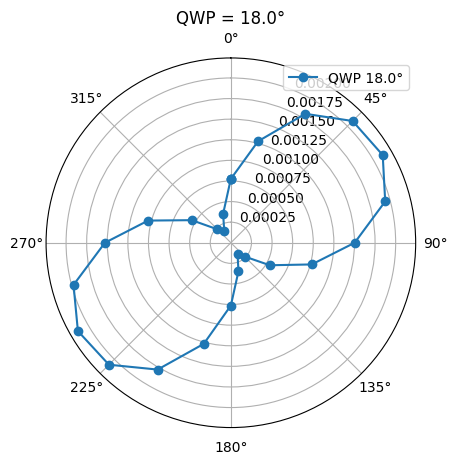


Setting QWP to 27.0°
  Polarizer 0.0°, QWP 27.0° → 1.0190e-03 W
  Polarizer 15.0°, QWP 27.0° → 1.4499e-03 W
  Polarizer 30.0°, QWP 27.0° → 1.8139e-03 W
  Polarizer 45.0°, QWP 27.0° → 1.9775e-03 W
  Polarizer 60.0°, QWP 27.0° → 1.9455e-03 W
  Polarizer 75.0°, QWP 27.0° → 1.6842e-03 W
  Polarizer 90.0°, QWP 27.0° → 1.3091e-03 W
  Polarizer 105.0°, QWP 27.0° → 8.9212e-04 W
  Polarizer 120.0°, QWP 27.0° → 5.3121e-04 W
  Polarizer 135.0°, QWP 27.0° → 3.5416e-04 W
  Polarizer 150.0°, QWP 27.0° → 3.8289e-04 W
  Polarizer 165.0°, QWP 27.0° → 6.2434e-04 W
  Polarizer 180.0°, QWP 27.0° → 1.0120e-03 W
  Polarizer 195.0°, QWP 27.0° → 1.4284e-03 W
  Polarizer 210.0°, QWP 27.0° → 1.8108e-03 W
  Polarizer 225.0°, QWP 27.0° → 1.9859e-03 W
  Polarizer 240.0°, QWP 27.0° → 1.9348e-03 W
  Polarizer 255.0°, QWP 27.0° → 1.6970e-03 W
  Polarizer 270.0°, QWP 27.0° → 1.3306e-03 W
  Polarizer 285.0°, QWP 27.0° → 8.7982e-04 W
  Polarizer 300.0°, QWP 27.0° → 5.3197e-04 W
  Polarizer 315.0°, QWP 27.0° → 3.4803e-0

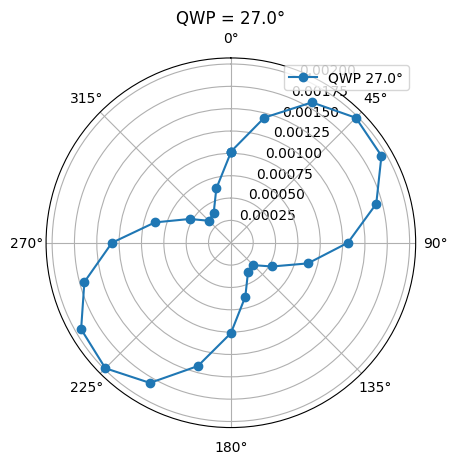


Setting QWP to 36.0°
  Polarizer 0.0°, QWP 36.0° → 1.0819e-03 W
  Polarizer 15.0°, QWP 36.0° → 1.3694e-03 W
  Polarizer 30.0°, QWP 36.0° → 1.5914e-03 W
  Polarizer 45.0°, QWP 36.0° → 1.7020e-03 W
  Polarizer 60.0°, QWP 36.0° → 1.6703e-03 W
  Polarizer 75.0°, QWP 36.0° → 1.5073e-03 W
  Polarizer 90.0°, QWP 36.0° → 1.2517e-03 W
  Polarizer 105.0°, QWP 36.0° → 9.6170e-04 W
  Polarizer 120.0°, QWP 36.0° → 7.3428e-04 W
  Polarizer 135.0°, QWP 36.0° → 6.2170e-04 W
  Polarizer 150.0°, QWP 36.0° → 6.4837e-04 W
  Polarizer 165.0°, QWP 36.0° → 8.1558e-04 W
  Polarizer 180.0°, QWP 36.0° → 1.0795e-03 W
  Polarizer 195.0°, QWP 36.0° → 1.3616e-03 W
  Polarizer 210.0°, QWP 36.0° → 1.5878e-03 W
  Polarizer 225.0°, QWP 36.0° → 1.7429e-03 W
  Polarizer 240.0°, QWP 36.0° → 1.6777e-03 W
  Polarizer 255.0°, QWP 36.0° → 1.4999e-03 W
  Polarizer 270.0°, QWP 36.0° → 1.2489e-03 W
  Polarizer 285.0°, QWP 36.0° → 9.6390e-04 W
  Polarizer 300.0°, QWP 36.0° → 7.3530e-04 W
  Polarizer 315.0°, QWP 36.0° → 6.1856e-0

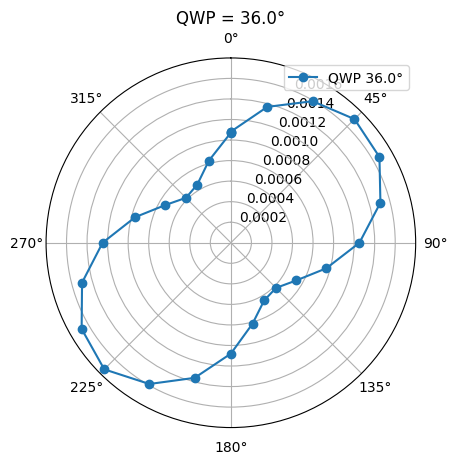


Setting QWP to 45.0°
  Polarizer 0.0°, QWP 45.0° → 9.3418e-04 W
  Polarizer 15.0°, QWP 45.0° → 1.0753e-03 W
  Polarizer 30.0°, QWP 45.0° → 1.2420e-03 W
  Polarizer 45.0°, QWP 45.0° → 1.3699e-03 W
  Polarizer 60.0°, QWP 45.0° → 1.4648e-03 W
  Polarizer 75.0°, QWP 45.0° → 1.4570e-03 W
  Polarizer 90.0°, QWP 45.0° → 1.3694e-03 W
  Polarizer 105.0°, QWP 45.0° → 1.2350e-03 W
  Polarizer 120.0°, QWP 45.0° → 1.0937e-03 W
  Polarizer 135.0°, QWP 45.0° → 9.4708e-04 W
  Polarizer 150.0°, QWP 45.0° → 8.5326e-04 W
  Polarizer 165.0°, QWP 45.0° → 8.5612e-04 W
  Polarizer 180.0°, QWP 45.0° → 9.3056e-04 W
  Polarizer 195.0°, QWP 45.0° → 1.0811e-03 W
  Polarizer 210.0°, QWP 45.0° → 1.2447e-03 W
  Polarizer 225.0°, QWP 45.0° → 1.3799e-03 W
  Polarizer 240.0°, QWP 45.0° → 1.4564e-03 W
  Polarizer 255.0°, QWP 45.0° → 1.4753e-03 W
  Polarizer 270.0°, QWP 45.0° → 1.3922e-03 W
  Polarizer 285.0°, QWP 45.0° → 1.2530e-03 W
  Polarizer 300.0°, QWP 45.0° → 1.0635e-03 W
  Polarizer 315.0°, QWP 45.0° → 9.3569e-0

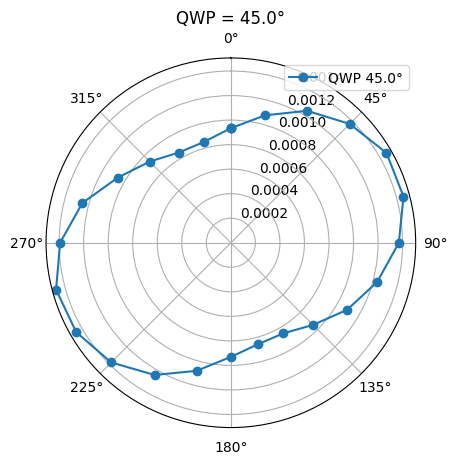


Setting QWP to 54.0°
  Polarizer 0.0°, QWP 54.0° → 6.4415e-04 W
  Polarizer 15.0°, QWP 54.0° → 6.8621e-04 W
  Polarizer 30.0°, QWP 54.0° → 8.5447e-04 W
  Polarizer 45.0°, QWP 54.0° → 1.1089e-03 W
  Polarizer 60.0°, QWP 54.0° → 1.3618e-03 W
  Polarizer 75.0°, QWP 54.0° → 1.5825e-03 W
  Polarizer 90.0°, QWP 54.0° → 1.6328e-03 W
  Polarizer 105.0°, QWP 54.0° → 1.5898e-03 W
  Polarizer 120.0°, QWP 54.0° → 1.4470e-03 W
  Polarizer 135.0°, QWP 54.0° → 1.1812e-03 W
  Polarizer 150.0°, QWP 54.0° → 9.3841e-04 W
  Polarizer 165.0°, QWP 54.0° → 7.4851e-04 W
  Polarizer 180.0°, QWP 54.0° → 6.4250e-04 W
  Polarizer 195.0°, QWP 54.0° → 6.8233e-04 W
  Polarizer 210.0°, QWP 54.0° → 8.4970e-04 W
  Polarizer 225.0°, QWP 54.0° → 1.1109e-03 W
  Polarizer 240.0°, QWP 54.0° → 1.3519e-03 W
  Polarizer 255.0°, QWP 54.0° → 1.5521e-03 W
  Polarizer 270.0°, QWP 54.0° → 1.6339e-03 W
  Polarizer 285.0°, QWP 54.0° → 1.5796e-03 W
  Polarizer 300.0°, QWP 54.0° → 1.4533e-03 W
  Polarizer 315.0°, QWP 54.0° → 1.1896e-0

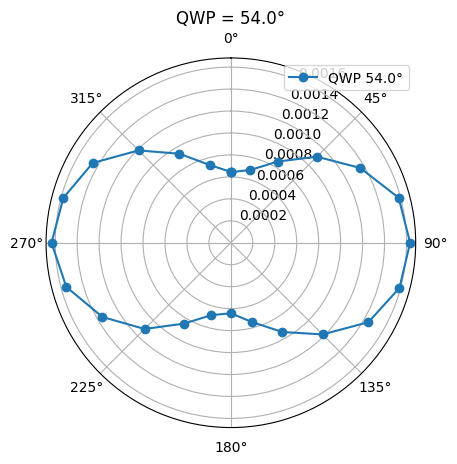


Setting QWP to 63.0°
  Polarizer 0.0°, QWP 63.0° → 3.1784e-04 W
  Polarizer 15.0°, QWP 63.0° → 3.2665e-04 W
  Polarizer 30.0°, QWP 63.0° → 5.5816e-04 W
  Polarizer 45.0°, QWP 63.0° → 9.3475e-04 W
  Polarizer 60.0°, QWP 63.0° → 1.3838e-03 W
  Polarizer 75.0°, QWP 63.0° → 1.7374e-03 W
  Polarizer 90.0°, QWP 63.0° → 1.9350e-03 W
  Polarizer 105.0°, QWP 63.0° → 1.9141e-03 W
  Polarizer 120.0°, QWP 63.0° → 1.6918e-03 W
  Polarizer 135.0°, QWP 63.0° → 1.3280e-03 W
  Polarizer 150.0°, QWP 63.0° → 9.1588e-04 W
  Polarizer 165.0°, QWP 63.0° → 5.4194e-04 W
  Polarizer 180.0°, QWP 63.0° → 3.2119e-04 W
  Polarizer 195.0°, QWP 63.0° → 3.2605e-04 W
  Polarizer 210.0°, QWP 63.0° → 5.5107e-04 W
  Polarizer 225.0°, QWP 63.0° → 9.2583e-04 W
  Polarizer 240.0°, QWP 63.0° → 1.3458e-03 W
  Polarizer 255.0°, QWP 63.0° → 1.7303e-03 W
  Polarizer 270.0°, QWP 63.0° → 1.9114e-03 W
  Polarizer 285.0°, QWP 63.0° → 1.9204e-03 W
  Polarizer 300.0°, QWP 63.0° → 1.7191e-03 W
  Polarizer 315.0°, QWP 63.0° → 1.3369e-0

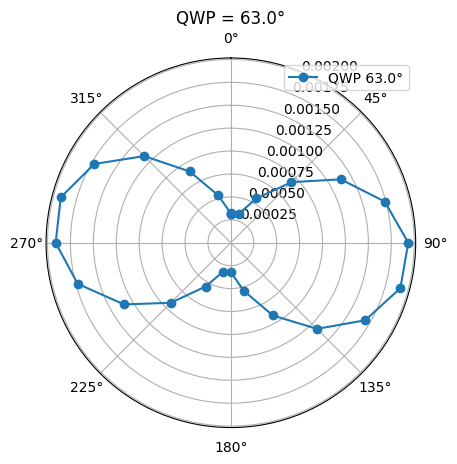


Setting QWP to 72.0°
  Polarizer 0.0°, QWP 72.0° → 9.8497e-05 W
  Polarizer 15.0°, QWP 72.0° → 1.2731e-04 W
  Polarizer 30.0°, QWP 72.0° → 4.2397e-04 W
  Polarizer 45.0°, QWP 72.0° → 9.1476e-04 W
  Polarizer 60.0°, QWP 72.0° → 1.4436e-03 W
  Polarizer 75.0°, QWP 72.0° → 1.8960e-03 W
  Polarizer 90.0°, QWP 72.0° → 2.1112e-03 W
  Polarizer 105.0°, QWP 72.0° → 2.0915e-03 W
  Polarizer 120.0°, QWP 72.0° → 1.7956e-03 W
  Polarizer 135.0°, QWP 72.0° → 1.3626e-03 W
  Polarizer 150.0°, QWP 72.0° → 8.2150e-04 W
  Polarizer 165.0°, QWP 72.0° → 3.5560e-04 W
  Polarizer 180.0°, QWP 72.0° → 1.0175e-04 W
  Polarizer 195.0°, QWP 72.0° → 1.2205e-04 W
  Polarizer 210.0°, QWP 72.0° → 4.1372e-04 W
  Polarizer 225.0°, QWP 72.0° → 8.9555e-04 W
  Polarizer 240.0°, QWP 72.0° → 1.4250e-03 W
  Polarizer 255.0°, QWP 72.0° → 1.8850e-03 W
  Polarizer 270.0°, QWP 72.0° → 2.1615e-03 W
  Polarizer 285.0°, QWP 72.0° → 2.1112e-03 W
  Polarizer 300.0°, QWP 72.0° → 1.8092e-03 W
  Polarizer 315.0°, QWP 72.0° → 1.3508e-0

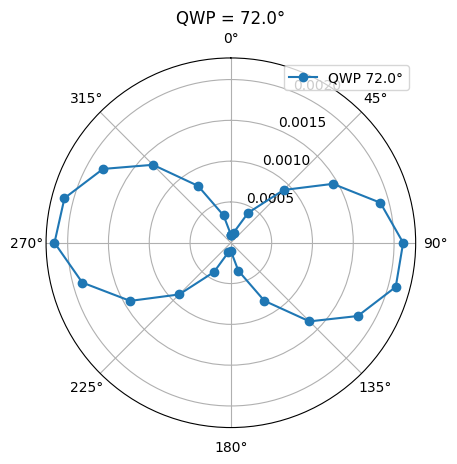


Setting QWP to 81.0°
  Polarizer 0.0°, QWP 81.0° → 6.8110e-05 W
  Polarizer 15.0°, QWP 81.0° → 1.3119e-04 W
  Polarizer 30.0°, QWP 81.0° → 4.6189e-04 W
  Polarizer 45.0°, QWP 81.0° → 9.7105e-04 W
  Polarizer 60.0°, QWP 81.0° → 1.5091e-03 W
  Polarizer 75.0°, QWP 81.0° → 1.9636e-03 W
  Polarizer 90.0°, QWP 81.0° → 2.1775e-03 W
  Polarizer 105.0°, QWP 81.0° → 2.0894e-03 W
  Polarizer 120.0°, QWP 81.0° → 1.7807e-03 W
  Polarizer 135.0°, QWP 81.0° → 1.2777e-03 W
  Polarizer 150.0°, QWP 81.0° → 7.4841e-04 W
  Polarizer 165.0°, QWP 81.0° → 3.0399e-04 W
  Polarizer 180.0°, QWP 81.0° → 7.0708e-05 W
  Polarizer 195.0°, QWP 81.0° → 1.2471e-04 W
  Polarizer 210.0°, QWP 81.0° → 4.5059e-04 W
  Polarizer 225.0°, QWP 81.0° → 9.5603e-04 W
  Polarizer 240.0°, QWP 81.0° → 1.4931e-03 W
  Polarizer 255.0°, QWP 81.0° → 1.9557e-03 W
  Polarizer 270.0°, QWP 81.0° → 2.1657e-03 W
  Polarizer 285.0°, QWP 81.0° → 2.0910e-03 W
  Polarizer 300.0°, QWP 81.0° → 1.7655e-03 W
  Polarizer 315.0°, QWP 81.0° → 1.2578e-0

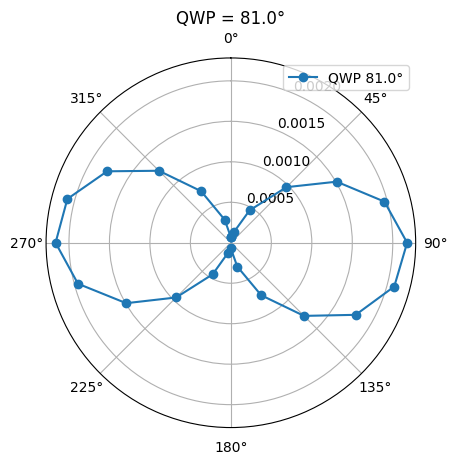


Setting QWP to 90.0°
  Polarizer 0.0°, QWP 90.0° → 2.4954e-04 W
  Polarizer 15.0°, QWP 90.0° → 3.1789e-04 W
  Polarizer 30.0°, QWP 90.0° → 6.1801e-04 W
  Polarizer 45.0°, QWP 90.0° → 1.0372e-03 W
  Polarizer 60.0°, QWP 90.0° → 1.4832e-03 W
  Polarizer 75.0°, QWP 90.0° → 1.8433e-03 W
  Polarizer 90.0°, QWP 90.0° → 1.9772e-03 W
  Polarizer 105.0°, QWP 90.0° → 1.9280e-03 W
  Polarizer 120.0°, QWP 90.0° → 1.6617e-03 W
  Polarizer 135.0°, QWP 90.0° → 1.2116e-03 W
  Polarizer 150.0°, QWP 90.0° → 7.7748e-04 W
  Polarizer 165.0°, QWP 90.0° → 4.1819e-04 W
  Polarizer 180.0°, QWP 90.0° → 2.4967e-04 W
  Polarizer 195.0°, QWP 90.0° → 3.0886e-04 W
  Polarizer 210.0°, QWP 90.0° → 5.9593e-04 W
  Polarizer 225.0°, QWP 90.0° → 1.0243e-03 W
  Polarizer 240.0°, QWP 90.0° → 1.4724e-03 W
  Polarizer 255.0°, QWP 90.0° → 1.8326e-03 W
  Polarizer 270.0°, QWP 90.0° → 2.0029e-03 W
  Polarizer 285.0°, QWP 90.0° → 1.9151e-03 W
  Polarizer 300.0°, QWP 90.0° → 1.7023e-03 W
  Polarizer 315.0°, QWP 90.0° → 1.2289e-0

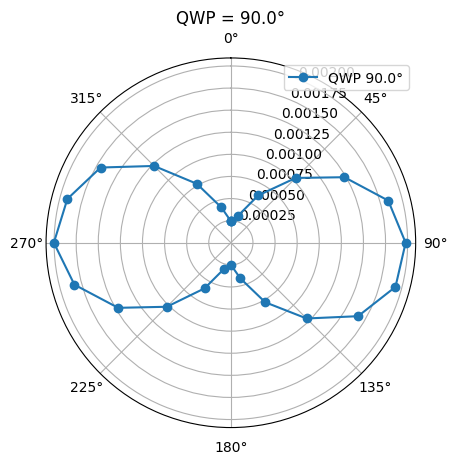


Setting QWP to 99.0°
  Polarizer 0.0°, QWP 99.0° → 5.6827e-04 W
  Polarizer 15.0°, QWP 99.0° → 5.9090e-04 W
  Polarizer 30.0°, QWP 99.0° → 7.6230e-04 W
  Polarizer 45.0°, QWP 99.0° → 1.0359e-03 W
  Polarizer 60.0°, QWP 99.0° → 1.3540e-03 W
  Polarizer 75.0°, QWP 99.0° → 1.5786e-03 W
  Polarizer 90.0°, QWP 99.0° → 1.6963e-03 W
  Polarizer 105.0°, QWP 99.0° → 1.7033e-03 W
  Polarizer 120.0°, QWP 99.0° → 1.5207e-03 W
  Polarizer 135.0°, QWP 99.0° → 1.2462e-03 W
  Polarizer 150.0°, QWP 99.0° → 9.5186e-04 W
  Polarizer 165.0°, QWP 99.0° → 7.0562e-04 W
  Polarizer 180.0°, QWP 99.0° → 5.7120e-04 W
  Polarizer 195.0°, QWP 99.0° → 5.8876e-04 W
  Polarizer 210.0°, QWP 99.0° → 7.5712e-04 W
  Polarizer 225.0°, QWP 99.0° → 1.0350e-03 W
  Polarizer 240.0°, QWP 99.0° → 1.3047e-03 W
  Polarizer 255.0°, QWP 99.0° → 1.5476e-03 W
  Polarizer 270.0°, QWP 99.0° → 1.7075e-03 W
  Polarizer 285.0°, QWP 99.0° → 1.6653e-03 W
  Polarizer 300.0°, QWP 99.0° → 1.5094e-03 W
  Polarizer 315.0°, QWP 99.0° → 1.2441e-0

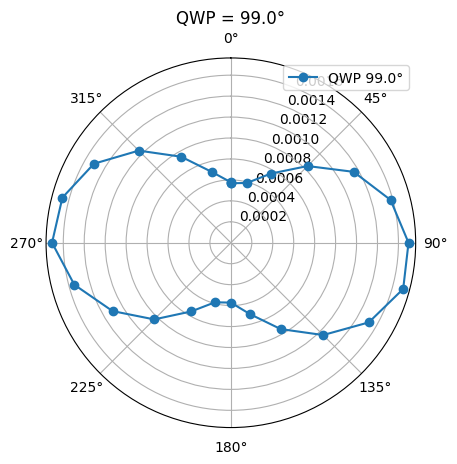


Setting QWP to 108.0°
  Polarizer 0.0°, QWP 108.0° → 9.4208e-04 W
  Polarizer 15.0°, QWP 108.0° → 8.3979e-04 W
  Polarizer 30.0°, QWP 108.0° → 8.3238e-04 W
  Polarizer 45.0°, QWP 108.0° → 9.1355e-04 W
  Polarizer 60.0°, QWP 108.0° → 1.0666e-03 W
  Polarizer 75.0°, QWP 108.0° → 1.2276e-03 W
  Polarizer 90.0°, QWP 108.0° → 1.3623e-03 W
  Polarizer 105.0°, QWP 108.0° → 1.4612e-03 W
  Polarizer 120.0°, QWP 108.0° → 1.4583e-03 W
  Polarizer 135.0°, QWP 108.0° → 1.3838e-03 W
  Polarizer 150.0°, QWP 108.0° → 1.2428e-03 W
  Polarizer 165.0°, QWP 108.0° → 1.0989e-03 W
  Polarizer 180.0°, QWP 108.0° → 9.4446e-04 W
  Polarizer 195.0°, QWP 108.0° → 8.4157e-04 W
  Polarizer 210.0°, QWP 108.0° → 8.3330e-04 W
  Polarizer 225.0°, QWP 108.0° → 9.0890e-04 W
  Polarizer 240.0°, QWP 108.0° → 1.0521e-03 W
  Polarizer 255.0°, QWP 108.0° → 1.2426e-03 W
  Polarizer 270.0°, QWP 108.0° → 1.3584e-03 W
  Polarizer 285.0°, QWP 108.0° → 1.4478e-03 W
  Polarizer 300.0°, QWP 108.0° → 1.5010e-03 W
  Polarizer 315.0°,

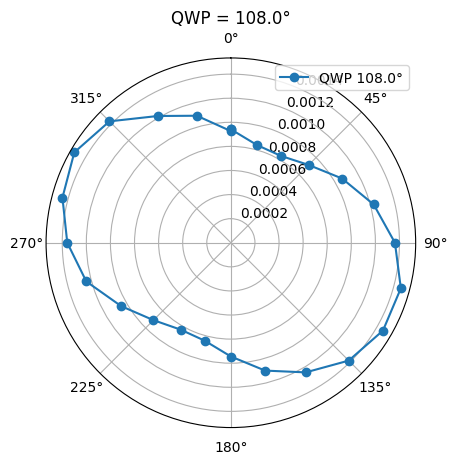


Setting QWP to 117.0°
  Polarizer 0.0°, QWP 117.0° → 1.2080e-03 W
  Polarizer 15.0°, QWP 117.0° → 9.4731e-04 W
  Polarizer 30.0°, QWP 117.0° → 7.6332e-04 W
  Polarizer 45.0°, QWP 117.0° → 6.8359e-04 W
  Polarizer 60.0°, QWP 117.0° → 7.3564e-04 W
  Polarizer 75.0°, QWP 117.0° → 9.0304e-04 W
  Polarizer 90.0°, QWP 117.0° → 1.1216e-03 W
  Polarizer 105.0°, QWP 117.0° → 1.3521e-03 W
  Polarizer 120.0°, QWP 117.0° → 1.5476e-03 W
  Polarizer 135.0°, QWP 117.0° → 1.6223e-03 W
  Polarizer 150.0°, QWP 117.0° → 1.5857e-03 W
  Polarizer 165.0°, QWP 117.0° → 1.3985e-03 W
  Polarizer 180.0°, QWP 117.0° → 1.2171e-03 W
  Polarizer 195.0°, QWP 117.0° → 9.6401e-04 W
  Polarizer 210.0°, QWP 117.0° → 7.6848e-04 W
  Polarizer 225.0°, QWP 117.0° → 6.8576e-04 W
  Polarizer 240.0°, QWP 117.0° → 7.3224e-04 W
  Polarizer 255.0°, QWP 117.0° → 8.8466e-04 W
  Polarizer 270.0°, QWP 117.0° → 1.1238e-03 W
  Polarizer 285.0°, QWP 117.0° → 1.3602e-03 W
  Polarizer 300.0°, QWP 117.0° → 1.5330e-03 W
  Polarizer 315.0°,

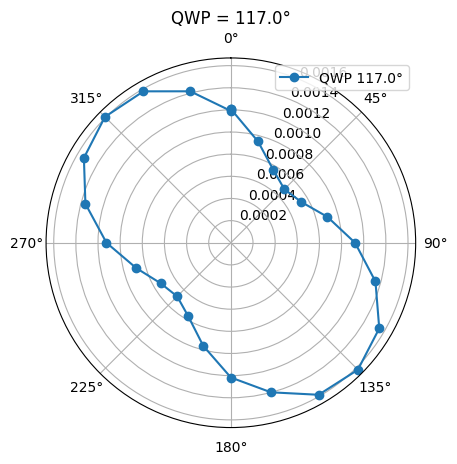


Setting QWP to 126.0°
  Polarizer 0.0°, QWP 126.0° → 1.2533e-03 W
  Polarizer 15.0°, QWP 126.0° → 8.8569e-04 W
  Polarizer 30.0°, QWP 126.0° → 5.7156e-04 W
  Polarizer 45.0°, QWP 126.0° → 4.2486e-04 W
  Polarizer 60.0°, QWP 126.0° → 4.7338e-04 W
  Polarizer 75.0°, QWP 126.0° → 7.0719e-04 W
  Polarizer 90.0°, QWP 126.0° → 1.0588e-03 W
  Polarizer 105.0°, QWP 126.0° → 1.4460e-03 W
  Polarizer 120.0°, QWP 126.0° → 1.7374e-03 W
  Polarizer 135.0°, QWP 126.0° → 1.8941e-03 W
  Polarizer 150.0°, QWP 126.0° → 1.8464e-03 W
  Polarizer 165.0°, QWP 126.0° → 1.6250e-03 W
  Polarizer 180.0°, QWP 126.0° → 1.2777e-03 W
  Polarizer 195.0°, QWP 126.0° → 8.9856e-04 W
  Polarizer 210.0°, QWP 126.0° → 5.7693e-04 W
  Polarizer 225.0°, QWP 126.0° → 4.2366e-04 W
  Polarizer 240.0°, QWP 126.0° → 4.7089e-04 W
  Polarizer 255.0°, QWP 126.0° → 7.0146e-04 W
  Polarizer 270.0°, QWP 126.0° → 1.0513e-03 W
  Polarizer 285.0°, QWP 126.0° → 1.4213e-03 W
  Polarizer 300.0°, QWP 126.0° → 1.7217e-03 W
  Polarizer 315.0°,

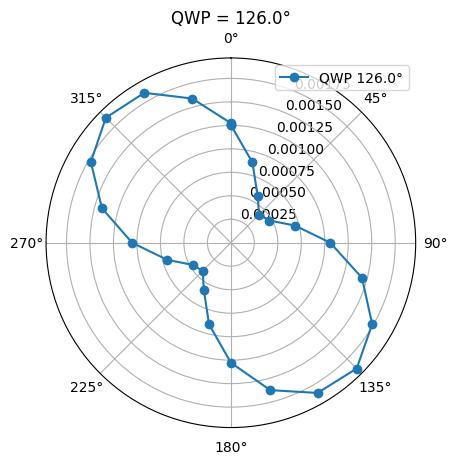


Setting QWP to 135.0°
  Polarizer 0.0°, QWP 135.0° → 1.1086e-03 W
  Polarizer 15.0°, QWP 135.0° → 6.4826e-04 W
  Polarizer 30.0°, QWP 135.0° → 3.1640e-04 W
  Polarizer 45.0°, QWP 135.0° → 2.2135e-04 W
  Polarizer 60.0°, QWP 135.0° → 3.7342e-04 W
  Polarizer 75.0°, QWP 135.0° → 7.3310e-04 W
  Polarizer 90.0°, QWP 135.0° → 1.1907e-03 W
  Polarizer 105.0°, QWP 135.0° → 1.6604e-03 W
  Polarizer 120.0°, QWP 135.0° → 1.9736e-03 W
  Polarizer 135.0°, QWP 135.0° → 2.0674e-03 W
  Polarizer 150.0°, QWP 135.0° → 1.9280e-03 W
  Polarizer 165.0°, QWP 135.0° → 1.5613e-03 W
  Polarizer 180.0°, QWP 135.0° → 1.1065e-03 W
  Polarizer 195.0°, QWP 135.0° → 6.5800e-04 W
  Polarizer 210.0°, QWP 135.0° → 3.2760e-04 W
  Polarizer 225.0°, QWP 135.0° → 2.2476e-04 W
  Polarizer 240.0°, QWP 135.0° → 3.6724e-04 W
  Polarizer 255.0°, QWP 135.0° → 7.1933e-04 W
  Polarizer 270.0°, QWP 135.0° → 1.1647e-03 W
  Polarizer 285.0°, QWP 135.0° → 1.6470e-03 W
  Polarizer 300.0°, QWP 135.0° → 1.9673e-03 W
  Polarizer 315.0°,

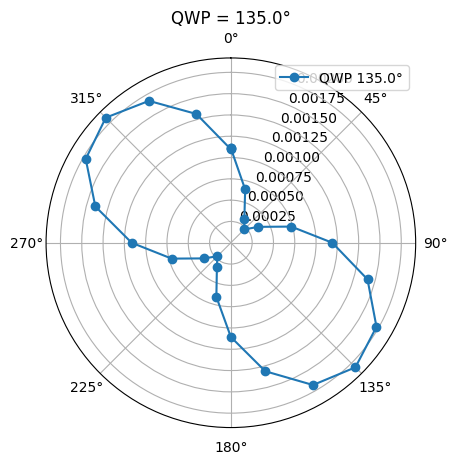


Setting QWP to 144.0°
  Polarizer 0.0°, QWP 144.0° → 7.8290e-04 W
  Polarizer 15.0°, QWP 144.0° → 3.4610e-04 W
  Polarizer 30.0°, QWP 144.0° → 1.2294e-04 W
  Polarizer 45.0°, QWP 144.0° → 1.7781e-04 W
  Polarizer 60.0°, QWP 144.0° → 4.9219e-04 W
  Polarizer 75.0°, QWP 144.0° → 9.7607e-04 W
  Polarizer 90.0°, QWP 144.0° → 1.4929e-03 W
  Polarizer 105.0°, QWP 144.0° → 1.9251e-03 W
  Polarizer 120.0°, QWP 144.0° → 2.1258e-03 W
  Polarizer 135.0°, QWP 144.0° → 2.1122e-03 W
  Polarizer 150.0°, QWP 144.0° → 1.8150e-03 W
  Polarizer 165.0°, QWP 144.0° → 1.3133e-03 W
  Polarizer 180.0°, QWP 144.0° → 7.9915e-04 W
  Polarizer 195.0°, QWP 144.0° → 3.5717e-04 W
  Polarizer 210.0°, QWP 144.0° → 1.2604e-04 W
  Polarizer 225.0°, QWP 144.0° → 1.7179e-04 W
  Polarizer 240.0°, QWP 144.0° → 4.7573e-04 W
  Polarizer 255.0°, QWP 144.0° → 9.6252e-04 W
  Polarizer 270.0°, QWP 144.0° → 1.4832e-03 W
  Polarizer 285.0°, QWP 144.0° → 1.9678e-03 W
  Polarizer 300.0°, QWP 144.0° → 2.1573e-03 W
  Polarizer 315.0°,

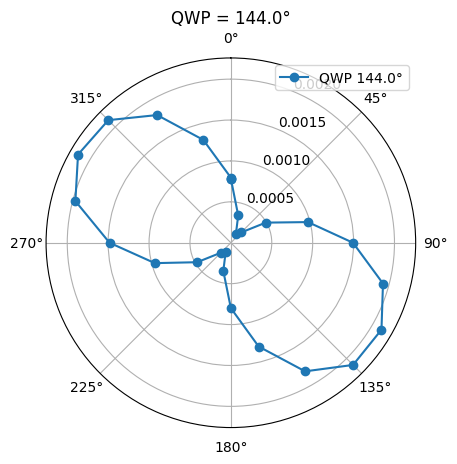


Setting QWP to 153.0°
  Polarizer 0.0°, QWP 153.0° → 4.2133e-04 W
  Polarizer 15.0°, QWP 153.0° → 1.1486e-04 W
  Polarizer 30.0°, QWP 153.0° → 8.5314e-05 W
  Polarizer 45.0°, QWP 153.0° → 3.3877e-04 W
  Polarizer 60.0°, QWP 153.0° → 8.0218e-04 W
  Polarizer 75.0°, QWP 153.0° → 1.3579e-03 W
  Polarizer 90.0°, QWP 153.0° → 1.8569e-03 W
  Polarizer 105.0°, QWP 153.0° → 2.1445e-03 W
  Polarizer 120.0°, QWP 153.0° → 2.1691e-03 W
  Polarizer 135.0°, QWP 153.0° → 1.9222e-03 W
  Polarizer 150.0°, QWP 153.0° → 1.4779e-03 W
  Polarizer 165.0°, QWP 153.0° → 9.4346e-04 W
  Polarizer 180.0°, QWP 153.0° → 4.3674e-04 W
  Polarizer 195.0°, QWP 153.0° → 1.2062e-04 W
  Polarizer 210.0°, QWP 153.0° → 8.2129e-05 W
  Polarizer 225.0°, QWP 153.0° → 3.2757e-04 W
  Polarizer 240.0°, QWP 153.0° → 8.0114e-04 W
  Polarizer 255.0°, QWP 153.0° → 1.3427e-03 W
  Polarizer 270.0°, QWP 153.0° → 1.8226e-03 W
  Polarizer 285.0°, QWP 153.0° → 2.1285e-03 W
  Polarizer 300.0°, QWP 153.0° → 2.1901e-03 W
  Polarizer 315.0°,

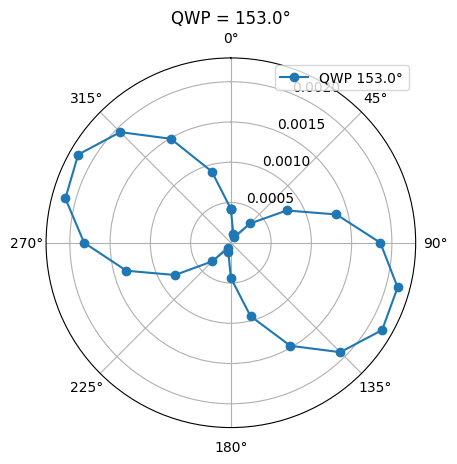


Setting QWP to 162.0°
  Polarizer 0.0°, QWP 162.0° → 1.3919e-04 W
  Polarizer 15.0°, QWP 162.0° → 5.0472e-05 W
  Polarizer 30.0°, QWP 162.0° → 2.5257e-04 W
  Polarizer 45.0°, QWP 162.0° → 6.9900e-04 W
  Polarizer 60.0°, QWP 162.0° → 1.2544e-03 W
  Polarizer 75.0°, QWP 162.0° → 1.7531e-03 W
  Polarizer 90.0°, QWP 162.0° → 2.0991e-03 W
  Polarizer 105.0°, QWP 162.0° → 2.1817e-03 W
  Polarizer 120.0°, QWP 162.0° → 1.9948e-03 W
  Polarizer 135.0°, QWP 162.0° → 1.5529e-03 W
  Polarizer 150.0°, QWP 162.0° → 1.0245e-03 W
  Polarizer 165.0°, QWP 162.0° → 5.0515e-04 W
  Polarizer 180.0°, QWP 162.0° → 1.4400e-04 W
  Polarizer 195.0°, QWP 162.0° → 4.8896e-05 W
  Polarizer 210.0°, QWP 162.0° → 2.4422e-04 W
  Polarizer 225.0°, QWP 162.0° → 6.8212e-04 W
  Polarizer 240.0°, QWP 162.0° → 1.2297e-03 W
  Polarizer 255.0°, QWP 162.0° → 1.7618e-03 W
  Polarizer 270.0°, QWP 162.0° → 2.1017e-03 W
  Polarizer 285.0°, QWP 162.0° → 2.1956e-03 W
  Polarizer 300.0°, QWP 162.0° → 1.9896e-03 W
  Polarizer 315.0°,

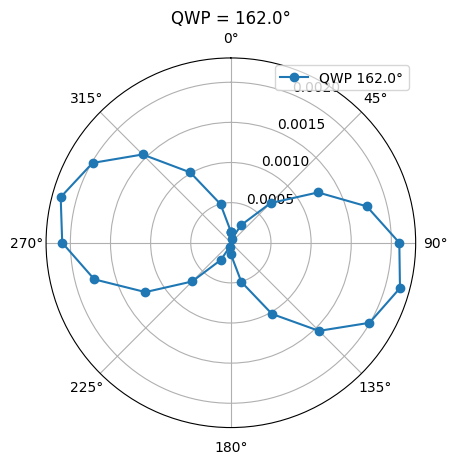


Setting QWP to 171.0°
  Polarizer 0.0°, QWP 171.0° → 4.0506e-05 W
  Polarizer 15.0°, QWP 171.0° → 2.0000e-04 W
  Polarizer 30.0°, QWP 171.0° → 6.1244e-04 W
  Polarizer 45.0°, QWP 171.0° → 1.1586e-03 W
  Polarizer 60.0°, QWP 171.0° → 1.7046e-03 W
  Polarizer 75.0°, QWP 171.0° → 2.0671e-03 W
  Polarizer 90.0°, QWP 171.0° → 2.2110e-03 W
  Polarizer 105.0°, QWP 171.0° → 2.0404e-03 W
  Polarizer 120.0°, QWP 171.0° → 1.6313e-03 W
  Polarizer 135.0°, QWP 171.0° → 1.1016e-03 W
  Polarizer 150.0°, QWP 171.0° → 5.7358e-04 W
  Polarizer 165.0°, QWP 171.0° → 1.8124e-04 W
  Polarizer 180.0°, QWP 171.0° → 3.8784e-05 W
  Polarizer 195.0°, QWP 171.0° → 1.9178e-04 W
  Polarizer 210.0°, QWP 171.0° → 5.9676e-04 W
  Polarizer 225.0°, QWP 171.0° → 1.1477e-03 W
  Polarizer 240.0°, QWP 171.0° → 1.6839e-03 W
  Polarizer 255.0°, QWP 171.0° → 2.0485e-03 W
  Polarizer 270.0°, QWP 171.0° → 2.2152e-03 W
  Polarizer 285.0°, QWP 171.0° → 2.0464e-03 W
  Polarizer 300.0°, QWP 171.0° → 1.6410e-03 W
  Polarizer 315.0°,

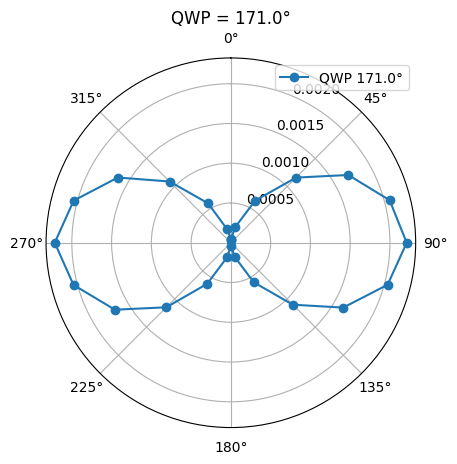


Setting QWP to 180.0°
  Polarizer 0.0°, QWP 180.0° → 1.5188e-04 W
  Polarizer 15.0°, QWP 180.0° → 5.2506e-04 W
  Polarizer 30.0°, QWP 180.0° → 1.0645e-03 W
  Polarizer 45.0°, QWP 180.0° → 1.5990e-03 W
  Polarizer 60.0°, QWP 180.0° → 2.0399e-03 W
  Polarizer 75.0°, QWP 180.0° → 2.2053e-03 W
  Polarizer 90.0°, QWP 180.0° → 2.1243e-03 W
  Polarizer 105.0°, QWP 180.0° → 1.7046e-03 W
  Polarizer 120.0°, QWP 180.0° → 1.2114e-03 W
  Polarizer 135.0°, QWP 180.0° → 6.6472e-04 W
  Polarizer 150.0°, QWP 180.0° → 2.4169e-04 W
  Polarizer 165.0°, QWP 180.0° → 4.6633e-05 W
  Polarizer 180.0°, QWP 180.0° → 1.4547e-04 W
  Polarizer 195.0°, QWP 180.0° → 5.1766e-04 W
  Polarizer 210.0°, QWP 180.0° → 1.0652e-03 W
  Polarizer 225.0°, QWP 180.0° → 1.5938e-03 W
  Polarizer 240.0°, QWP 180.0° → 2.0299e-03 W
  Polarizer 255.0°, QWP 180.0° → 2.2087e-03 W
  Polarizer 270.0°, QWP 180.0° → 2.0850e-03 W
  Polarizer 285.0°, QWP 180.0° → 1.7508e-03 W
  Polarizer 300.0°, QWP 180.0° → 1.2119e-03 W
  Polarizer 315.0°,

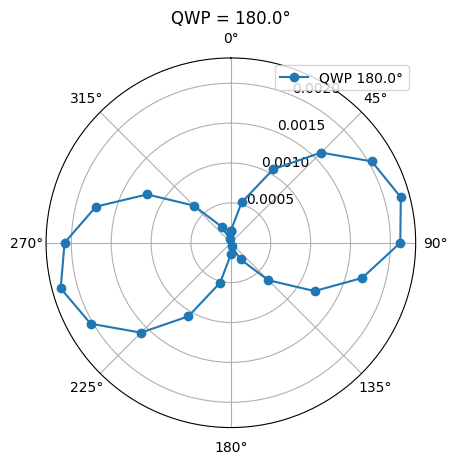

Data saved to 'power_map_20251124_151432.csv' and 'polarization_map_20251124_151432.png'


<Figure size 640x480 with 0 Axes>

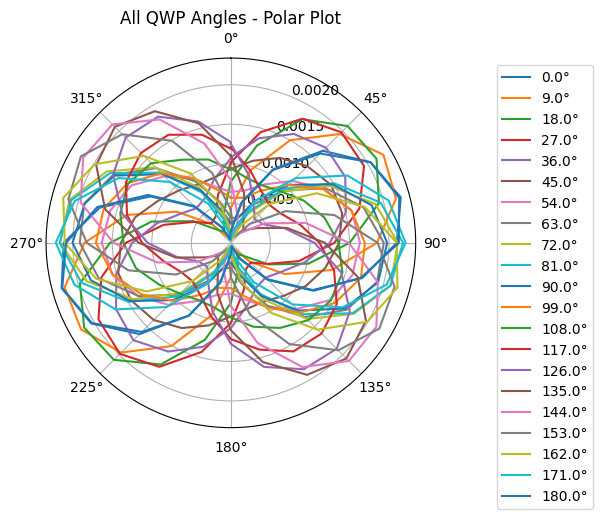

'\ndef polarization_scan(pm, polarizer, qwp, flip_mount, laser_wavelength=532, save=True,\n                      pol_start=0, qwp_start=0, pol_step_num=25, qwp_stop=180, qwp_step=9):\n'

In [20]:
df = polarization_scan(pm=pm2,polarizer=rm1,qwp=rm2,flip_mount=fm,laser_wavelength=wavelength)
"""
def polarization_scan(pm, polarizer, qwp, flip_mount, laser_wavelength=532, save=True,
                      pol_start=0, qwp_start=0, pol_step_num=25, qwp_stop=180, qwp_step=9):
"""

In [11]:
#df = polarization_scan(pm=pm,polarizer=rm1,qwp=rm2,flip_mount=fm,laser_wavelength=wavelength)

def fit_incident_from_scan(df):
    xp = df.index.astype(float).values # Analyzer angles
    for col in df.columns:
        intensity = df[col].values
    
        # initial guess
        Ai0 = intensity.max()
        xi0 = xp[np.argmax(intensity)]   # rough guess
        p0  = 0.0   
    
        p0_list = [Ai0, xi0, p0]
        bounds = ([0, -180, -180], [np.inf, 180, 180])
    
        try:
            popt, pcov = curve_fit(incident_model, xp, intensity, p0=p0_list, bounds=bounds,maxfev=10000)
            Ai, xi, p = popt
            results[col] = {"Ai": Ai, "xi_deg": xi, "p_deg": p, "cov": pov}
    
            print(f"[OK] Column {col}: xi = {xi:.2f}°, p = {p:.2f}°")
            
        except RuntimeError:
            print(f"[FAIL] Column {col}: Fit did not converge")
            results[col] = None
    return results

incident_results = fit_incident_from_scan(df)
xi_init = incident_results["0.0"]["xi_deg"]
p_init  = incident_results["0.0"]["p_deg"]

print(results["0.0"])

NameError: name 'df' is not defined

In [ ]:
OAM = [-3, -2, -1, 0, 1, 2, 3]
Power = [1.72e-3, 1.74e-3, 1.75e-3, 1.75e-3, 1.76e-3, 1.75e-3, 1.73e-3] #Power for each OAM
tolerance = 1e-6 
#cycle_number = 40


for i in range(len(OAM)):
    set_OAM(OAM[i], shift_x = 150, shift_y = 0)
    setpoint = Power[i]
    set_power(setpoint, 1e-6)
    #lOCK MEASUREMENT
    
    time.sleep(1)
    flip_mount.move_to_state(0) #Block
    
   

In [10]:
OAM = np.arange(-5,6,1)
qwp = np.arange(0,181,9)
sample_power = 1e-4
tolerance = 1e-6
print(OAM)
print(qwp)

sample_list = []
error_list = []
source_list = []
OAM_list = []
qwp_list = []

for l in OAM:
    set_OAM(l)
    for p in qwp:
        rm2.move_to(p)
        sample,error,source = set_sample_power(sample_power,tolerance, fm, pm1, pm2, nd, 1e-3)
        print(f"Sample power: {sample}, Source power: {source}")
        sample_list.append(sample)
        error_list.append(error)
        source_list.append(source)
        OAM_list.append(OAM)
        qwp_list.append(qwp)
        
        


[-5 -4 -3 -2 -1  0  1  2  3  4  5]
[  0   9  18  27  36  45  54  63  72  81  90  99 108 117 126 135 144 153
 162 171 180]


'\nfor l in OAM:\n    set_OAM(l)\n    for qwp in \n'

In [ ]:
for l,p,source in zip(OAM_list,qwp_list,source_list):
    set_OAM(l)
    rm2.move_to(p)
    set_power(source)
    
        